In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.5_all_data.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.5_all_data.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.5_all_data.tsv", sep="\t")

fold2_05["fold"] = [0 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [6]:
fold0_10 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-1.0_all_data_extra.tsv", sep="\t")

fold0_10["fold"] = [0 for i in range(len(fold0_10))]
fold0_10["target"] = [-1.0 for i in range(len(fold0_10))]

In [7]:
fold1_10 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-1.0_all_data_extra.tsv", sep="\t")

fold1_10["fold"] = [1 for i in range(len(fold1_10))]
fold1_10["target"] = [-1.0 for i in range(len(fold1_10))]

In [8]:
fold2_10 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-1.0_all_data_extra.tsv", sep="\t")

fold2_10["fold"] = [2 for i in range(len(fold2_10))]
fold2_10["target"] = [-1.0 for i in range(len(fold2_10))]

In [9]:
fold0_50 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-5.0_all_data_extra.tsv", sep="\t")

fold0_50["fold"] = [0 for i in range(len(fold0_50))]
fold0_50["target"] = [-5.0 for i in range(len(fold0_50))]

In [10]:
fold1_50 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-5.0_all_data_extra.tsv", sep="\t")

fold1_50["fold"] = [1 for i in range(len(fold1_50))]
fold1_50["target"] = [-5.0 for i in range(len(fold1_50))]

In [11]:
fold2_50 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-5.0_all_data_extra.tsv", sep="\t")

fold2_50["fold"] = [2 for i in range(len(fold2_50))]
fold2_50["target"] = [-5.0 for i in range(len(fold2_50))]

In [12]:
fold0_100 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-10.0_all_data_extra.tsv", sep="\t")

fold0_100["fold"] = [0 for i in range(len(fold0_100))]
fold0_100["target"] = [-10.0 for i in range(len(fold0_100))]

In [13]:
fold1_100 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-10.0_all_data_extra.tsv", sep="\t")

fold1_100["fold"] = [1 for i in range(len(fold1_100))]
fold1_100["target"] = [-10.0 for i in range(len(fold1_100))]

In [14]:
fold2_100 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-10.0_all_data_extra.tsv", sep="\t")

fold2_100["fold"] = [2 for i in range(len(fold2_100))]
fold2_100["target"] = [-10.0 for i in range(len(fold2_100))]

In [15]:
df = pd.concat([fold0_05, fold1_05, fold2_05, 
                fold0_10, fold1_10, fold2_10,
                fold0_50, fold1_50, fold2_50,
                fold0_100, fold1_100, fold2_100], ignore_index=True)

In [16]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'fold', 'target', 'start', 'end',
       'PearsonR', 'flat_start', 'flat_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'orientation', 'positions'],
      dtype='object')

In [17]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [18]:
df['optimization_successful'] = df['SCD'] > 30

In [19]:
natural_results_path = "/scratch1/smaruj/natural_boundaries_URQmean/all_boundaries_URQ_mean.tsv"
nat_df = pd.read_csv(natural_results_path, sep="\t")

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

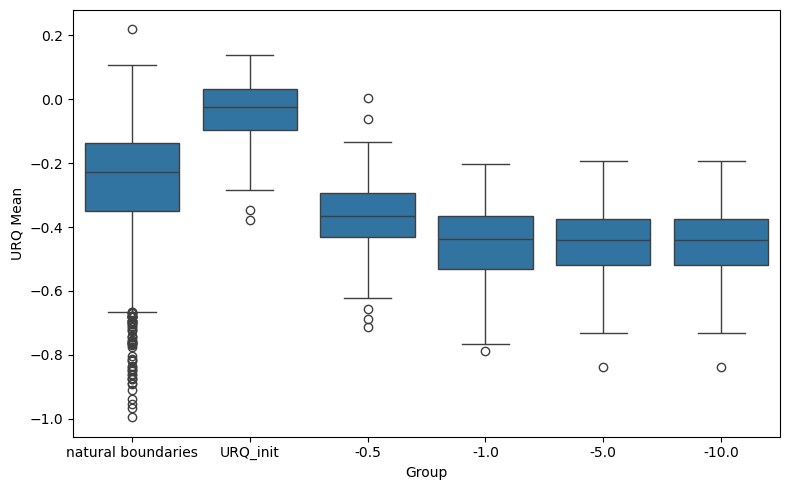

In [22]:
# 1. URQ_result for all targets
plot_df = df[['URQ_result', 'target']].copy()
plot_df['value'] = plot_df['URQ_result']
plot_df['group'] = plot_df['target'].astype(str)

# 3. URQ_mean from nat_df
nat_df_box = pd.DataFrame({
    'value': nat_df['URQ_mean'],
    'group': ['natural boundaries'] * len(nat_df)
})

# 2. URQ_init for target -0.5
init_subset = df[df['target'] == -0.5]
init_df = pd.DataFrame({
    'value': init_subset['URQ_init'],
    'group': ['URQ_init'] * len(init_subset)
})

# 4. Combine in desired order: URQ_mean, URQ_init, then URQ_result
combined_df = pd.concat(
    [nat_df_box, init_df, plot_df[['value', 'group']]],
    ignore_index=True
)

# 5. Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='value', data=combined_df)
plt.xlabel("Group")
plt.ylabel("URQ Mean")
plt.tight_layout()
plt.show()


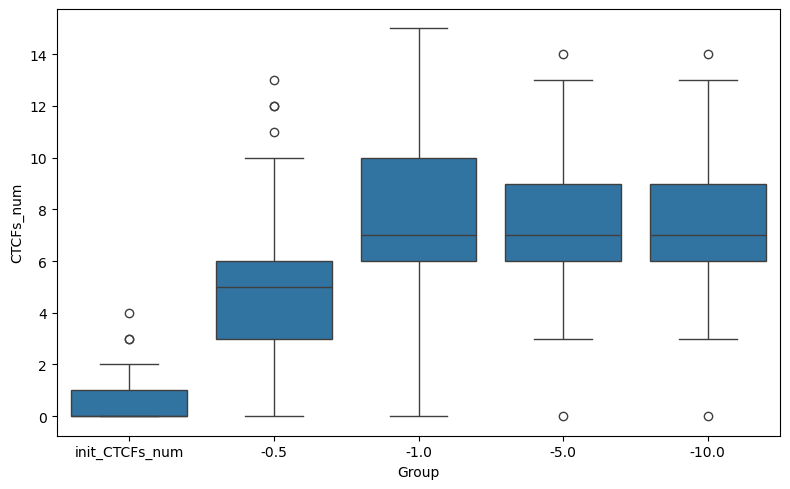

In [23]:
# 1. CTCFs_num for all targets
plot_df = df[['CTCFs_num', 'target']].copy()
plot_df['value'] = plot_df['CTCFs_num']
plot_df['group'] = plot_df['target'].astype(str)

# 2. init_CTCFs_num for target -0.5
init_subset = df[df['target'] == -0.5]
init_df = pd.DataFrame({
    'value': init_subset['init_CTCFs_num'],
    'group': ['init_CTCFs_num'] * len(init_subset)
})

# 3. Combine
combined_df = pd.concat([init_df, plot_df[['value', 'group']]], ignore_index=True)

# 4. Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='value', data=combined_df)
plt.xlabel("Group")
plt.ylabel("CTCFs_num")
# plt.title("CTCFs_num by Target Category with Initial CTCFs_num (-0.5)")
plt.tight_layout()
plt.show()

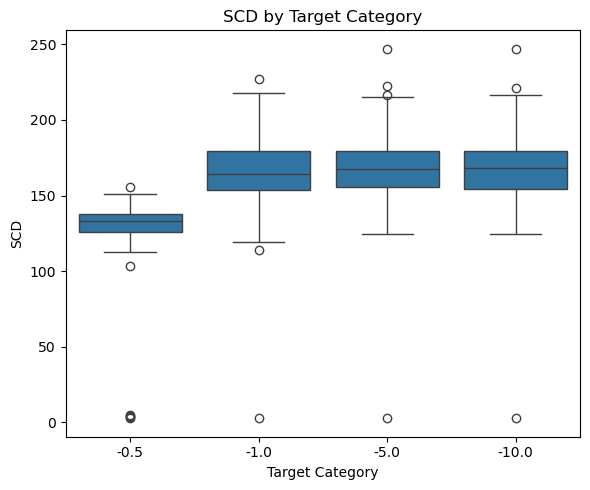

In [24]:
plot_df = df[['SCD', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='SCD', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("SCD")
plt.title("SCD by Target Category")
plt.tight_layout()
plt.show()

Pearson correlation (all targets + init): r = -0.429, p = 1.09e-30


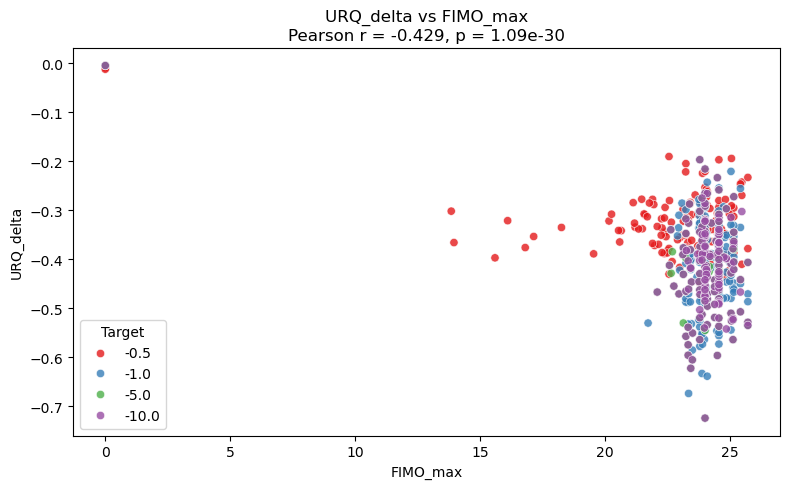

In [32]:
# 1. Compute URQ_delta for all relevant targets
subset = df[df['target'].isin([-0.5, -1.0, -5.0, -10.0])].copy()
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']
subset['Target'] = subset['target'].astype(str)  # Treat target as group label

# 3. Combine all data
plot_df = pd.concat([subset[['FIMO_max', 'URQ_delta', 'Target']]], ignore_index=True)

# # 4. Pearson correlation over full data
corr, pval = pearsonr(plot_df['FIMO_max'], plot_df['URQ_delta'])
print(f"Pearson correlation (all targets + init): r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x='FIMO_max',
    y='URQ_delta',
    hue='Target',
    palette='Set1',
    alpha=0.8
)
plt.xlabel("FIMO_max")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs FIMO_max\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

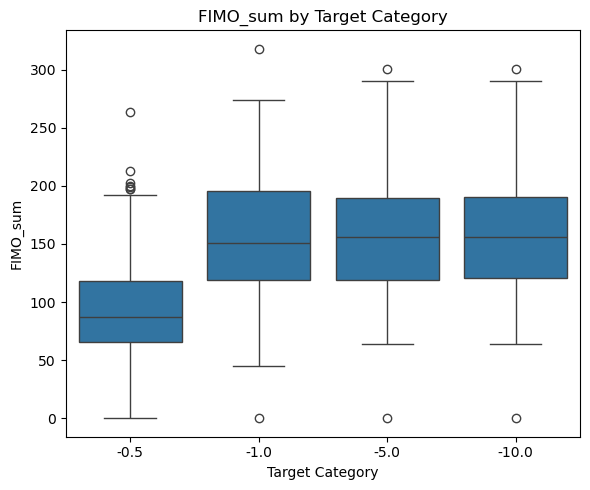

In [33]:
plot_df = df[['FIMO_sum', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='FIMO_sum', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by Target Category")
plt.tight_layout()
plt.show()

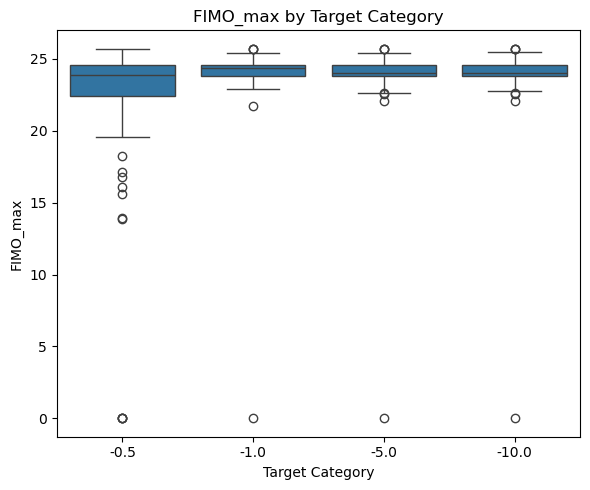

In [34]:
plot_df = df[['FIMO_max', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='FIMO_max', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by Target Category")
plt.tight_layout()
plt.show()

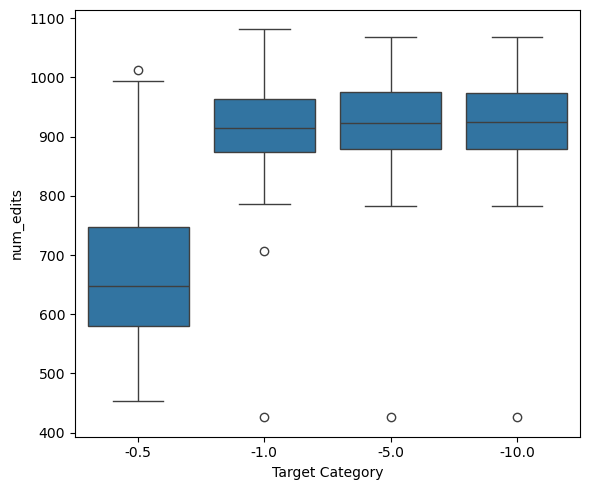

In [29]:
plot_df = df[['num_edits', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='num_edits', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("num_edits")
# plt.title("num_edits by Target Category")
plt.tight_layout()
plt.show()

In [38]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'fold', 'target', 'start', 'end',
       'PearsonR', 'flat_start', 'flat_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'orientation', 'positions',
       'URQ_delta', 'optimization_successful'],
      dtype='object')

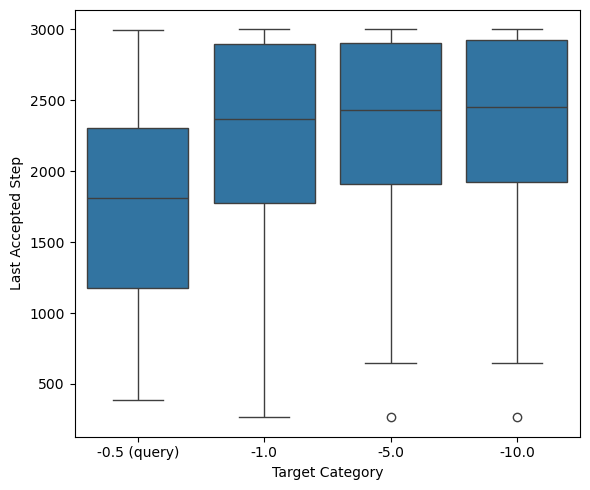

In [39]:
# Filter and rename for the two groups
df1 = df[df['target'] == -0.5][['last_accepted_step_query']].copy()
df1['value'] = df1['last_accepted_step_query']
df1['target'] = '-0.5 (query)'
df1 = df1[['target', 'value']]

df2 = df[df['target'].isin([-1.0, -5.0, -10.0])][['last_accepted_step', 'target']].copy()
df2['value'] = df2['last_accepted_step']
df2['target'] = df2['target'].astype(str)
df2 = df2[['target', 'value']]

# Combine
plot_df = pd.concat([df1, df2], ignore_index=True)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='value', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("Last Accepted Step")
plt.tight_layout()
plt.show()

In [ ]:
df[df["target"] == -0.2]["CTCFs_num"].mean()

In [ ]:
df[df["target"] == -0.3]["CTCFs_num"].mean()

In [ ]:
df[df["target"] == -0.4]["CTCFs_num"].mean()

In [ ]:
df[df["target"] == -0.5]["CTCFs_num"].mean()